In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import warnings
from scipy.stats import friedmanchisquare
warnings.filterwarnings("ignore") 
from functools import reduce
from scikit_posthocs import posthoc_nemenyi_friedman

In [ ]:

DATA_DIR = Path("/Users/mlin2/Desktop/RabLab/tasks/concurrent/data/cleaned_dat")

# clean bl
dat_bl = pd.read_csv(DATA_DIR / "merged_baseline_wDemo.csv")
dat_bl = dat_bl[dat_bl.dx.isin(["EOAD","EOnonAD"])]
eoad_ids = dat_bl[dat_bl.dx=="EOAD"].subject_label.tolist()

# clean long
def exclude_tx(df):
    return df[df.tx_started == 0].drop(
        columns=["tx_start_date", "tx_started"]
    ) 
def filter_longitudinal(df, eoad_ids, id_col="subject_label"):
    # eoad IDs
    df = df[df[id_col].isin(eoad_ids)].copy()

    # >=2 tps
    valid_ids = (
        df[id_col]
        .value_counts()
        .loc[lambda x: x >= 2]
        .index
    )

    return df[df[id_col].isin(valid_ids)].copy()
long_byptau = pd.read_csv(DATA_DIR / "ptau_ref_long_only_eoad_90d.csv")

ptau_final = exclude_tx(pd.read_csv(DATA_DIR / "ptau_cleaned_20260330.csv"))
tau_final  = exclude_tx(pd.read_csv(DATA_DIR / "tau_cleaned_20260330.csv"))
amy_final  = exclude_tx(pd.read_csv(DATA_DIR / "amy_cleaned_20260330.csv"))
cdr_final  = exclude_tx(pd.read_csv(DATA_DIR / "cdr_cleaned_20260330.csv"))
moca_final = exclude_tx(pd.read_csv(DATA_DIR / "moca_cleaned_20260330.csv"))
ptau_final = filter_longitudinal(ptau_final, eoad_ids)
tau_final  = filter_longitudinal(tau_final,  eoad_ids)
amy_final  = filter_longitudinal(amy_final,  eoad_ids)
cdr_final  = filter_longitudinal(cdr_final,  eoad_ids)
moca_final = filter_longitudinal(moca_final, eoad_ids)
ptau_final["log_ptau217"] = np.log(ptau_final["ptau217"]) 
long_byptau["log_ptau217"] = np.log(long_byptau["ptau217"]) 
dat_bl["log_ptau217"] = np.log(dat_bl["ptau217"]) 

In [131]:

# --- define expected columns ---
expected_cols = {
    "ptau_final": ["log_ptau217", "day_to_baseline_ptau"],
    "tau_final": ["desikan_suvr", "day_to_baseline_tau"],
    "amy_final": ["centiloid_wcbl", "day_to_baseline_amy"],
    "cdr_final": ["cdrsb", "day_to_baseline_cdr"],
    "moca_final": ["moca", "day_to_baseline_moca"],
}

# --- check columns exist ---
for df_name, cols in expected_cols.items():
    df = globals().get(df_name)
    if df is None:
        raise ValueError(f"{df_name} not found in environment")

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing columns: {missing}")
    else:
        print(f"{df_name}: all required columns present")
 

ptau_final: all required columns present
tau_final: all required columns present
amy_final: all required columns present
cdr_final: all required columns present
moca_final: all required columns present


In [132]:
biomarkers = ["log_ptau217","desikan_suvr","centiloid_wcbl"]
cogs = ["moca","cdrsb"]

# validity (baseline clinical differentiation between EOAD and EOnonAD)
operationalized as difference between each group's deviation from the global mean


In [24]:
from utils.stats_utils import pooled_sd 
#take two lists and output the pooled sd 

In [25]:
def compute_diff_effect(df, biomarker, group_col="dx", sf=3):
    g = df[[biomarker, group_col]].dropna()

    # enforce two groups
    groups = g[group_col].unique()

    g1, g2 = groups

    x1 = g.loc[g[group_col] == g1, biomarker].values
    x2 = g.loc[g[group_col] == g2, biomarker].values

    sp = pooled_sd(x1, x2)

    d = abs(np.mean(x1) - np.mean(x2)) / sp

    return round(d,sf)

effect_sizes = {
    biom: compute_diff_effect(dat_bl, biom)
    for biom in biomarkers
}

effect_sizes

{'log_ptau217': 2.883, 'desikan_suvr': 1.92, 'centiloid_wcbl': 3.967}

In [26]:
def compute_diff_W(df, biomarkers, group_col="dx", id_col="subject_label"):
    W_dfs = []

    for biomarker in biomarkers:
        d = df[[id_col, biomarker, group_col]].dropna().copy()

        biomarker_mean = d[biomarker].mean()

        # group sizes
        group_N = d[group_col].value_counts().to_dict()
        groups = list(group_N.keys())

        # pooled SD
        x1 = d.loc[d[group_col] == groups[0], biomarker]
        x2 = d.loc[d[group_col] == groups[1], biomarker]

        sp = pooled_sd(x1, x2)

        group_map = {groups[0]: 1, groups[1]: 2}

        def compute_row(row):
            k = group_map[row[group_col]]
            nk = group_N[row[group_col]]
            sign = (-1)**(k - 1) # for all three EOAD has higher biomarke values than EOnonAD
            return sign * (row[biomarker] - biomarker_mean) / nk / sp

        d[biomarker] = d.apply(compute_row, axis=1)

        W = d[[id_col, biomarker]]

        W_dfs.append(W)

    # merge all biomarker W on subject ID
    W_mat = reduce(lambda left, right: pd.merge(left, right, on=id_col), W_dfs)

    return W_mat

## between EOnonAD and EOAD

In [27]:
W_mat = compute_diff_W(dat_bl, biomarkers)
arrays = [W_mat[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)
print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")

#rank
print("Ranking average W (larger = better)")
print(dict(W_mat[biomarkers].mean().sort_values(ascending=False)))

# run post hoc
posthoc = posthoc_nemenyi_friedman(W_mat[biomarkers])
print("Post hoc (Nemenyi) p-values:")
print(posthoc)

Friedman test statistic: 125.9658
p-value: 4.4348e-28
Ranking average W (larger = better)
{'centiloid_wcbl': 0.0072186563864373495, 'log_ptau217': 0.005957604911340491, 'desikan_suvr': 0.0036005936056928683}
Post hoc (Nemenyi) p-values:
                 log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217     1.000000e+00  3.652634e-14        0.003885
desikan_suvr    3.652634e-14  1.000000e+00        0.000000
centiloid_wcbl  3.885151e-03  0.000000e+00        1.000000


## between dementia and mci?

In [28]:
W_mat_cd = compute_diff_W(
    dat_bl,
    biomarkers,
    group_col="clinical_severity_baseline",  
    id_col="subject_label"
)

# Friedman test
arrays = [W_mat_cd[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)

print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")

# ranking
print("Ranking average W (larger = better)")
print(dict(W_mat_cd[biomarkers].mean().sort_values(ascending=False)))

# post hoc (Nemenyi)
posthoc = posthoc_nemenyi_friedman(W_mat_cd[biomarkers])
print("Post hoc (Nemenyi) p-values:")
print(posthoc)

Friedman test statistic: 2.9079
p-value: 2.3364e-01
Ranking average W (larger = better)
{'desikan_suvr': 0.0017180610782143485, 'log_ptau217': 0.0016925551632097236, 'centiloid_wcbl': 0.0012681429042026007}
Post hoc (Nemenyi) p-values:
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217         1.00000       0.99060         0.33723
desikan_suvr        0.99060       1.00000         0.27318
centiloid_wcbl      0.33723       0.27318         1.00000


# precision annual change 
operationalized as sample size needed to detect 25% reduction in annual rate of change for a two-arm, equal-sized, 1-year clinical trial, asuming 80% power and alpha = 0.05

and to get the actual sample size: 
n = 2*(z_1−α/2​+z_1−β​)σ^2​/Δ^2
where z_1−α = 1.96; z_1−β = 0.84; Δ = 25% * annualized rate of change; σ = std of annualized rate of change

In [29]:
 
def compute_annual_change(df, biomarker, time_col, id_col="subject_label"):
    df = df[[id_col, biomarker, time_col]].dropna().copy()

    # sort by subject and time
    df = df.sort_values([id_col, time_col])

    # take first two visits per subject
    df = df.groupby(id_col).head(2)

    # keep only subjects with 2 visits
    counts = df[id_col].value_counts()
    valid_ids = counts[counts >= 2].index
    df = df[df[id_col].isin(valid_ids)]

    # compute delta
    df["delta_biomarker"] = df.groupby(id_col)[biomarker].diff()
    df["delta_time"] = df.groupby(id_col)[time_col].diff()
    df = df.dropna(subset=["delta_biomarker", "delta_time"])

    # annualized rate (days → years)
    df["R"] = df["delta_biomarker"] / (df["delta_time"] / 365.25)
    return df[[id_col, "R"]]

In [30]:
def compute_precision_W(df, biomarker, time_col, id_col="subject_label"):
    dR = compute_annual_change(df, biomarker, time_col, id_col)

    mean_R = dR["R"].mean() #biomarker mean

    dR["W"] = ((dR["R"] - mean_R)**2) / (mean_R**2)

    return dR[[id_col, "W"]]

In [31]:
W_precision_list = []

for biom in biomarkers:
    W_b = compute_precision_W(
        long_byptau[long_byptau.dx=="EOAD"],
        biomarker=biom,
        time_col="day_to_baseline_ptau"
    ).rename(columns={"W": biom})

    W_precision_list.append(W_b)
 
W_precision_mat = reduce(lambda l, r: pd.merge(l, r, on="subject_label"), W_precision_list)

In [32]:
arrays = [W_precision_mat[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)
print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")
print("Ranking precision (smaller = better)")
print(W_precision_mat[biomarkers].mean().sort_values())

Friedman test statistic: 71.9363
p-value: 2.3946e-16
Ranking precision (smaller = better)
desikan_suvr       1.808812
centiloid_wcbl    11.821046
log_ptau217       19.573194
dtype: float64


In [33]:
def compute_sample_size(df, biomarker, time_col):
    dR = compute_annual_change(df, biomarker, time_col)

    delta = dR["R"].mean()
    sigma = dR["R"].std(ddof=1)

    n = (2*(1.96+0.84)**2) * (sigma / (0.25*delta))**2  # per arm

    return n

sample_sizes = {
    biom: compute_sample_size(long_byptau, biom, "day_to_baseline_ptau")
    for biom in biomarkers
}

dict(sorted(sample_sizes.items(), key=lambda item: item[1]))

{'desikan_suvr': 456.7036450661111,
 'centiloid_wcbl': 2984.6745760621216,
 'log_ptau217': 4942.000740870012}

# validity of change  (dementia ver + lm)
 
SEEM TO NOT USE THE TP MATCHED DATA. 

In [ ]:
long_bycdr = pd.read_csv(DATA_DIR / "cdr_ref_long_only_eoad_90d.csv")
valid_ids = (
    long_bycdr["subject_label"]
    .value_counts()
    .loc[lambda x: x >= 2]
    .index
)
long_bycdr['log_ptau217'] = np.log(long_bycdr["ptau217"]) 
long_bycdr = long_bycdr[long_bycdr.subject_label.isin(valid_ids)]
long_bycdr.subject_label.nunique() # 

## cdr

In [ ]:
def compute_slopes( df, value_col, time_col,  id_col="subject_label", group_col="dx", group_val="EOAD"):
   
    slopes = []
    for sid, d in df.groupby(id_col):

        d = d.sort_values(time_col)
        if d[time_col].nunique() < 2: # in case of duplicates but really shouldnt
            continue
        x = d[time_col].values / 365.25 #annualized? 
        y = d[value_col].values
        # slope
        try:
            slope = np.polyfit(x, y, 1)[0]
            slopes.append((sid, slope))
        except:
            continue

    return pd.DataFrame(slopes, columns=[id_col, "slope"])

In [136]:
cdr_slopes = compute_slopes(
    cdr_final,
    value_col="cdrsb",
    time_col="day_to_baseline_cdr"
).rename(columns={"slope": "cdr_slope"}) 

time_map = {
    "log_ptau217": "day_to_baseline_ptau",
    "desikan_suvr": "day_to_baseline_tau",
    "centiloid_wcbl": "day_to_baseline_amy"
}

ptau_final["log_ptau217"] = np.log(ptau_final["ptau217"])
df_map = {
    "log_ptau217": ptau_final,
    "desikan_suvr": tau_final,
    "centiloid_wcbl": amy_final
}

biomarker_slopes = {}

for biom in biomarkers:
    biomarker_slopes[biom] = compute_slopes(
        df_map[biom],
        value_col=biom,
        time_col=time_map[biom]
    ).rename(columns={"slope": f"{biom}_slope"}) 

 

bio_slopes_df = reduce(
    lambda left, right: pd.merge(left, right, on="subject_label"),
    biomarker_slopes.values()
)
df_slopes = pd.merge(
    bio_slopes_df,
    cdr_slopes,
    on="subject_label"
) 

In [137]:
print("Unique subjects (biomarkers):", bio_slopes_df.shape[0])
print("Unique subjects (CDR):", cdr_slopes.shape[0])
print("Final merged subjects:", df_slopes.shape[0])

Unique subjects (biomarkers): 191
Unique subjects (CDR): 272
Final merged subjects: 186


In [138]:

def compute_W_change(df, biomarkers, cog_col, id_col="subject_label"):
    W_list = []

    for biom in biomarkers:
        B = df[f"{biom}_slope"].values
        C = df[cog_col].values

        # correlation
        rho = np.corrcoef(B, C)[0, 1]

        # guard against near-zero correlation
        rho_safe = max(abs(rho), 1e-6)

        # regression fit (C ~ B)
        beta = np.polyfit(B, C, 1)
        C_pred = beta[0] * B + beta[1]

        # residuals
        r = C - C_pred

        # W calculation
        W = (r**2) / rho_safe

        tmp = pd.DataFrame({
            id_col: df[id_col],
            biom: W
        })
        W_list.append(tmp)

        # sanity
        print(f"{biom}: rho = {rho:.3f}")
    W_mat = reduce(lambda l, r: pd.merge(l, r, on=id_col), W_list)

    return W_mat

In [139]:
W_change = compute_W_change(df_slopes, biomarkers,"cdr_slope")

log_ptau217: rho = 0.006
desikan_suvr: rho = -0.060
centiloid_wcbl: rho = -0.189


In [141]:
 
arrays = [W_change[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)

print(f"Friedman test statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")

print("Ranking (smaller = better validity)")
print(W_change[biomarkers].mean().sort_values())

posthoc = posthoc_nemenyi_friedman(W_change[biomarkers])
print(posthoc)

Friedman test statistic: 325.4946
p-value: 2.0880e-71
Ranking (smaller = better validity)
centiloid_wcbl     11.452010
desikan_suvr       37.311993
log_ptau217       364.141522
dtype: float64
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217             1.0  0.000000e+00    0.000000e+00
desikan_suvr            0.0  1.000000e+00    1.476597e-14
centiloid_wcbl          0.0  1.476597e-14    1.000000e+00


## moca

In [142]:

long_bymoca = pd.read_csv(DATA_DIR / "moca_ref_long_only_eoad_90d.csv")
long_bymoca['log_ptau217'] = np.log(long_bymoca["ptau217"])
valid_ids = (
    long_bymoca["subject_label"]
    .value_counts()
    .loc[lambda x: x >= 2]
    .index
)
long_bymoca = long_bymoca[long_bymoca.subject_label.isin(valid_ids)]
long_bymoca.subject_label.nunique()

115

In [143]:
moca_slopes = compute_slopes(
    moca_final,
    value_col="moca",
    time_col="day_to_baseline_moca"
).rename(columns={"slope": "moca_slope"})
  
df_slopes_moca = pd.merge(
    bio_slopes_df,
    moca_slopes,
    on="subject_label"
)

W_change_moca = compute_W_change(
    df_slopes_moca,
    biomarkers,
    cog_col="moca_slope"
)

arrays = [W_change_moca[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)

print(f"Friedman test (MoCA): stat={stat:.4f}, p={p:.4e}")

print("\nRanking (MoCA, smaller W = better)")
print(W_change_moca[biomarkers].mean().sort_values())
 
if p < 0.05:
    print("\nPost hoc (Nemenyi, MoCA):")
    print(posthoc_nemenyi_friedman(W_change_moca[biomarkers]))
else:
    print("\nNo significant overall difference → skip post hoc")

log_ptau217: rho = 0.043
desikan_suvr: rho = -0.084
centiloid_wcbl: rho = 0.043
Friedman test (MoCA): stat=162.6154, p=4.8811e-36

Ranking (MoCA, smaller W = better)
desikan_suvr       59.149155
log_ptau217       116.518549
centiloid_wcbl    116.683191
dtype: float64

Post hoc (Nemenyi, MoCA):
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217        1.000000           0.0        0.938381
desikan_suvr       0.000000           1.0        0.000000
centiloid_wcbl     0.938381           0.0        1.000000


# validity of change (dementia ver + lme/cov option)

In [158]:

import statsmodels.formula.api as smf

def compute_slopes_lme(
    df,
    value_col,
    time_col,
    covariates=None,
    id_col="subject_label",
):

    df.dropna(subset=[value_col,time_col],inplace=True)
    # convert time to years
    df["time_years"] = df[time_col] / 365.25

    # uild formula
    formula = f"{value_col} ~ time_years"
    if covariates:
        formula += " + " + " + ".join(covariates)

    # fit mixed model (random intercept + slope)
    model = smf.mixedlm(
        formula,
        df,
        groups=df[id_col],
        re_formula="~time_years"
    )

    result = model.fit()

    # extract slopes
    fixed_slope = result.params["time_years"]

    slopes = []

    for sid, re in result.random_effects.items():
        # random slope component
        rand_slope = re.get("time_years", 0.0)

        subject_slope = fixed_slope + rand_slope
        slopes.append((sid, subject_slope))

    return pd.DataFrame(slopes, columns=[id_col, "slope"]), result

## cdr

In [ ]:
cdr_slopes_lme, _ = compute_slopes_lme(
    cdr_final,
    value_col="cdrsb",
    time_col="day_to_baseline_cdr",
    covariates=None
)
cdr_slopes_lme = cdr_slopes_lme.rename(columns={"slope": "cdr_slope"})


# --- biomarker slopes via LME ---
bio_slopes_lme = {}

for biom in biomarkers:
    slopes_df, _ = compute_slopes_lme(
        df_map[biom],
        value_col=biom,
        time_col=time_map[biom],
        covariates=None  # add if you have time-varying covariates
    )
    bio_slopes_lme[biom] = slopes_df.rename(columns={"slope": f"{biom}_slope"})

df_slopes = pd.merge(
    bio_slopes_df,
    cdr_slopes_lme,
    on="subject_label"
)

print("Final N:", df_slopes.shape[0])

Final N: 186


In [160]:
#sanity check
for i in df_slopes.subject_label:
    if i not in eoad_ids:
        print(i)

In [168]:
W_change = compute_W_change(df_slopes, biomarkers,"cdr_slope")
arrays = [W_change[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)

print(f"\nFriedman: stat={stat:.4f}, p={p:.4e}")
print("\nRanking (smaller W = better)")
print(W_change[biomarkers].mean().sort_values())
if p < 0.05:
    print("\nPost hoc (Nemenyi):")
    print(posthoc_nemenyi_friedman(W_change[biomarkers]))
else:
    print("\nNo significant overall difference → skip post hoc")

log_ptau217: rho = -0.001
desikan_suvr: rho = 0.015
centiloid_wcbl: rho = -0.094

Friedman: stat=358.2043, p=1.6479e-78

Ranking (smaller W = better)
centiloid_wcbl     11.144621
desikan_suvr       68.927102
log_ptau217       739.910849
dtype: float64

Post hoc (Nemenyi):
                log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217             1.0           0.0             0.0
desikan_suvr            0.0           1.0             0.0
centiloid_wcbl          0.0           0.0             1.0


## moca

In [169]:
moca_slopes_lme, _ = compute_slopes_lme(
    moca_final,
    value_col="moca",
    time_col="day_to_baseline_moca",
    covariates=None
)
moca_slopes_lme = moca_slopes_lme.rename(columns={"slope": "moca_slope"})
df_slopes = pd.merge(
    bio_slopes_df,
    moca_slopes_lme,
    on="subject_label"
)

print("Final N:", df_slopes.shape[0])

Final N: 169


In [170]:
W_change = compute_W_change(df_slopes, biomarkers,"moca_slope")
arrays = [W_change[b].values for b in biomarkers]
stat, p = friedmanchisquare(*arrays)

print(f"\nFriedman: stat={stat:.4f}, p={p:.4e}")
print("\nRanking (smaller W = better)")
print(W_change[biomarkers].mean().sort_values())
if p < 0.05:
    print("\nPost hoc (Nemenyi):")
    print(posthoc_nemenyi_friedman(W_change[biomarkers]))
else:
    print("\nNo significant overall difference → skip post hoc")

log_ptau217: rho = 0.058
desikan_suvr: rho = -0.160
centiloid_wcbl: rho = 0.026

Friedman: stat=245.6923, p=4.4524e-54

Ranking (smaller W = better)
desikan_suvr       6.859849
log_ptau217       19.312433
centiloid_wcbl    43.172264
dtype: float64

Post hoc (Nemenyi):
                 log_ptau217  desikan_suvr  centiloid_wcbl
log_ptau217     1.000000e+00  1.396722e-10             0.0
desikan_suvr    1.396722e-10  1.000000e+00             0.0
centiloid_wcbl  0.000000e+00  0.000000e+00             1.0


# debugging visualization

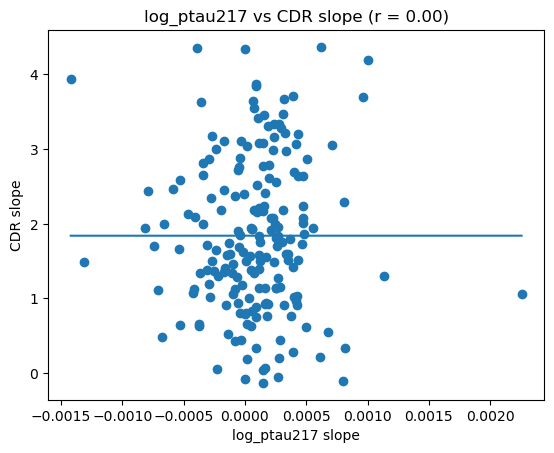

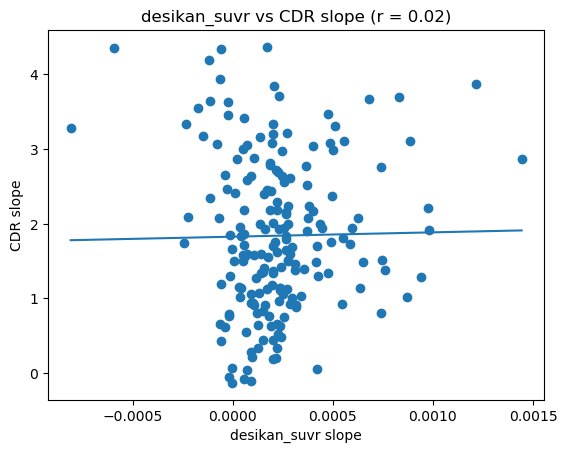

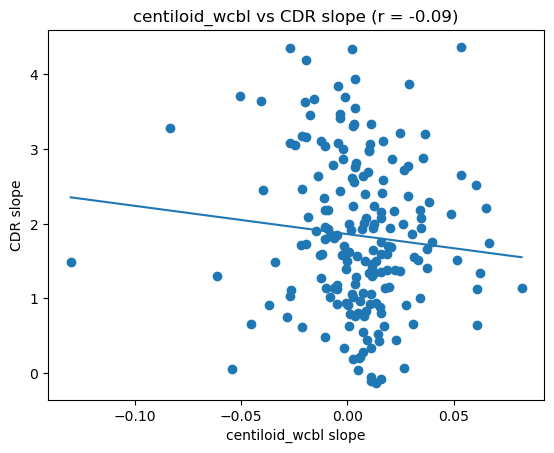

In [103]:
import matplotlib.pyplot as plt 

for biom in biomarkers:
    B = df_slopes[f"{biom}_slope"]
    C = df_slopes["cdr_slope"]

    # compute correlation
    rho = np.corrcoef(B, C)[0, 1]

    plt.figure()
    plt.scatter(B, C)

    # regression line
    m, b = np.polyfit(B, C, 1)
    x_vals = np.linspace(B.min(), B.max(), 100)
    plt.plot(x_vals, m*x_vals + b)

    plt.xlabel(f"{biom} slope")
    plt.ylabel("CDR slope")
    plt.title(f"{biom} vs CDR slope (r = {rho:.2f})")

    plt.show()